Maximum frequency = 2500 Hz
Nyquist rate = 5000 Hz

Above Nyquist
Sampling frequency = 8000 Hz
RMS reconstruction error = 0.0449573229380025
No aliasing expected.


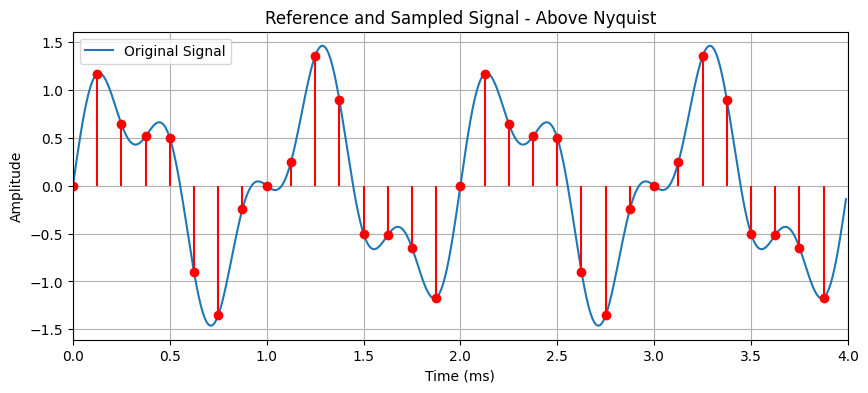

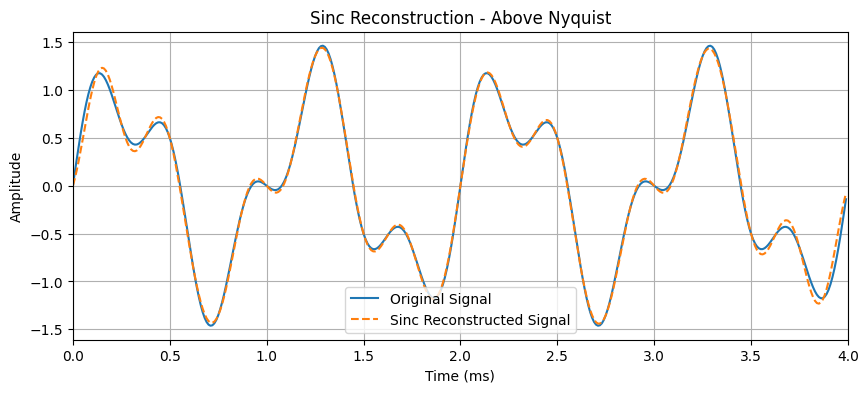

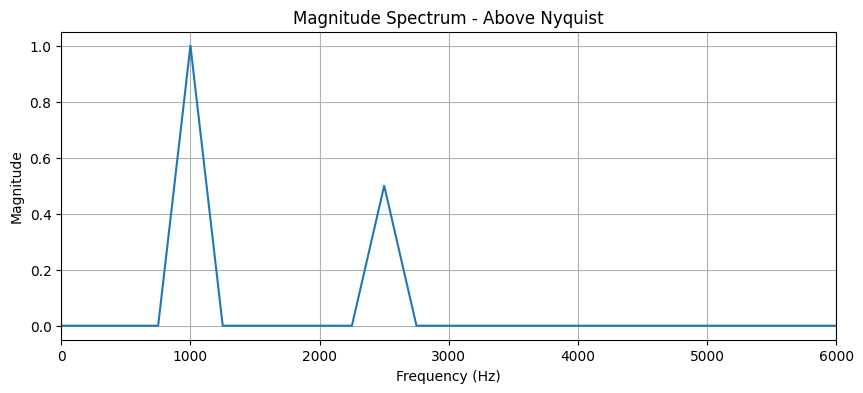

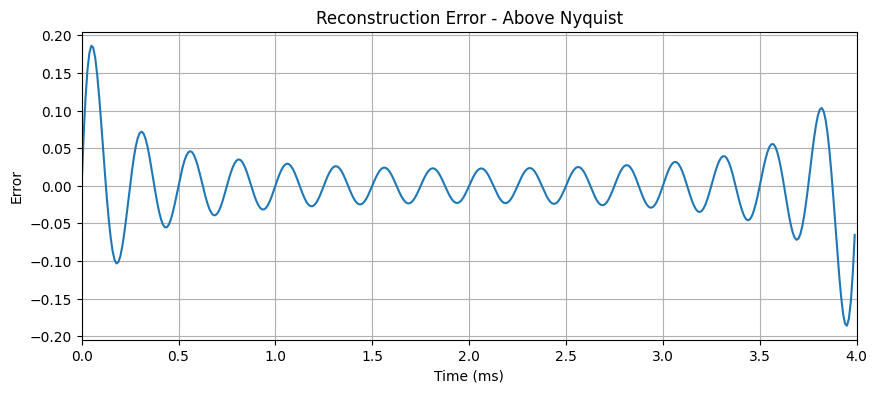


At Nyquist
Sampling frequency = 5000 Hz
RMS reconstruction error = 0.385638510224095
No aliasing expected.


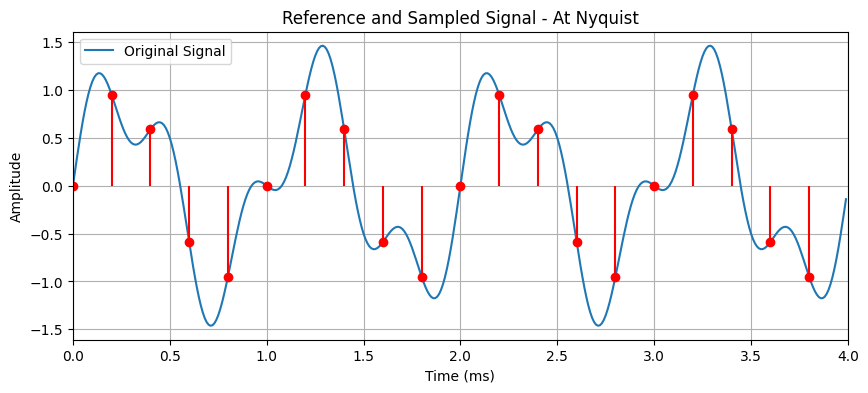

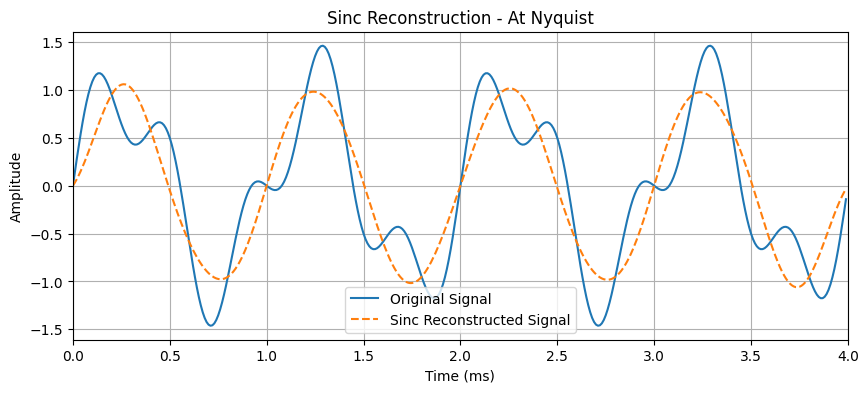

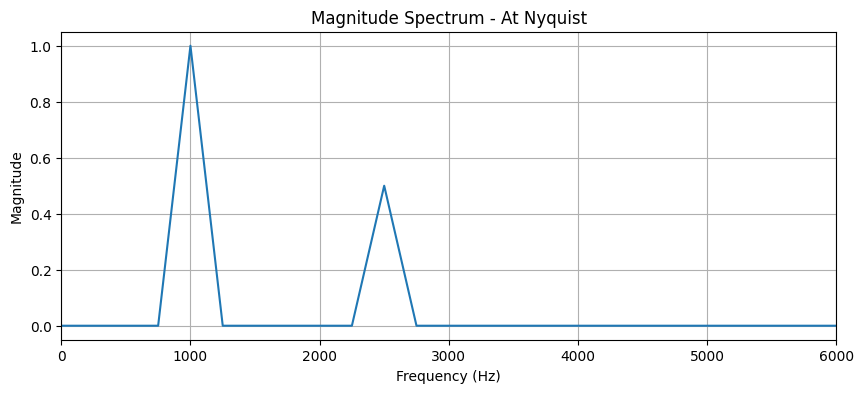

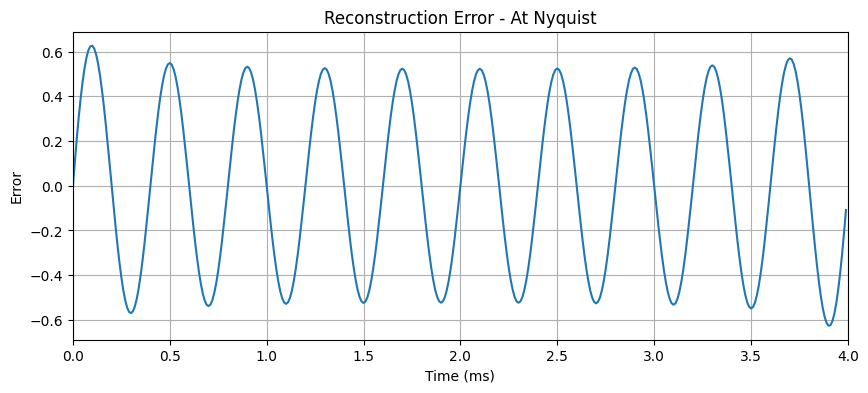


Below Nyquist
Sampling frequency = 4000 Hz
RMS reconstruction error = 0.5036561077342119
Aliased frequency = 1500 Hz


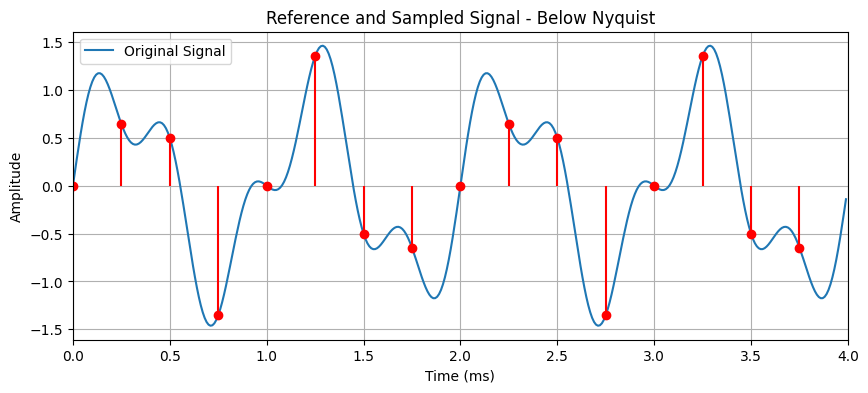

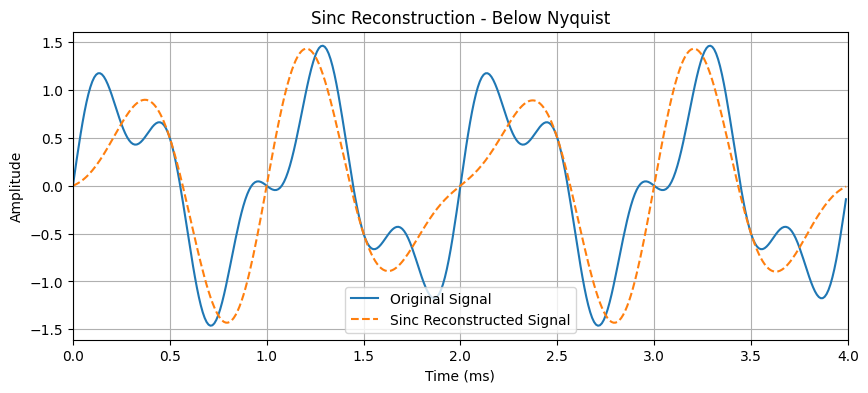

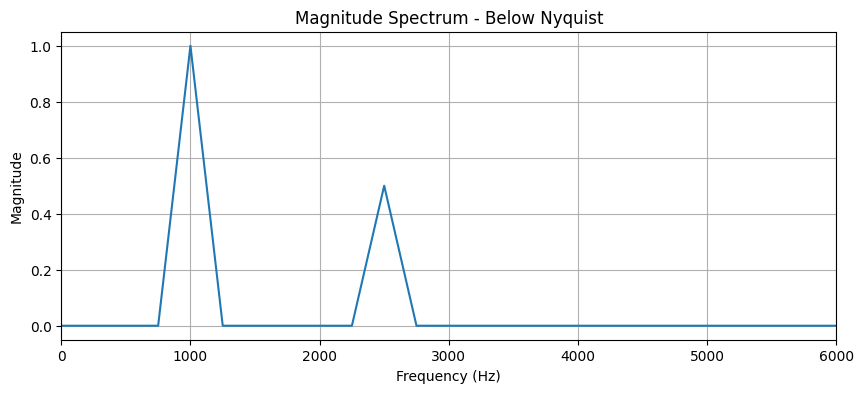

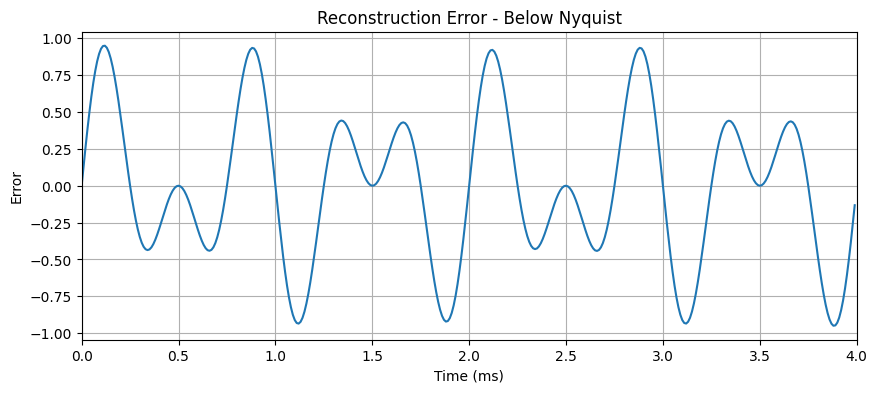


CONCLUSION
Nyquist rate = 5000 Hz
fs = 8000 Hz -> Above Nyquist -> No aliasing
fs = 5000 Hz -> At Nyquist
fs = 4000 Hz -> Below Nyquist -> Aliasing occurs


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Two-tone signal
f1 = 1000       # 1 kHz
f2 = 2500       # 2.5 kHz

fmax = max(f1, f2)
nyquist_rate = 2 * fmax

print("Maximum frequency =", fmax, "Hz")
print("Nyquist rate =", nyquist_rate, "Hz")

T = 0.004
Fs_cont = 100000

t = np.arange(0, T, 1/Fs_cont)

# x(t) = sin(2*pi*f1*t) + 0.5*sin(2*pi*f2*t)
x = np.sin(2*np.pi*f1*t) + 0.5*np.sin(2*np.pi*f2*t)

sampling_frequencies = [8000, 5000, 4000]
case_names = ["Above Nyquist", "At Nyquist", "Below Nyquist"]


for fs, case in zip(sampling_frequencies, case_names):

    print("\n======================================")
    print(case)
    print("Sampling frequency =", fs, "Hz")
    print("======================================")

    Ts = 1/fs

    ts = np.arange(0, T, Ts)

    xs = (np.sin(2*np.pi*f1*ts)
          + 0.5*np.sin(2*np.pi*f2*ts))

    xr = np.zeros_like(t)

    for n in range(len(ts)):
        xr += xs[n] * np.sinc((t - ts[n]) / Ts)


    error = x - xr

    rms_error = np.sqrt(np.mean(error**2))

    print("RMS reconstruction error =", rms_error)

    if fs < nyquist_rate:

        # Alias of f2
        f_alias = abs(f2 - round(f2/fs)*fs)

        if f_alias > fs/2:
            f_alias = fs - f_alias

        print("Aliased frequency =", f_alias, "Hz")

    else:
        print("No aliasing expected.")

    plt.figure(figsize=(10,4))

    plt.plot(t*1000, x, label="Original Signal")

    plt.stem(ts*1000, xs,
             linefmt='r-',
             markerfmt='ro',
             basefmt=' ')

    plt.xlabel("Time (ms)")
    plt.ylabel("Amplitude")
    plt.title("Reference and Sampled Signal - " + case)
    plt.legend()
    plt.grid()
    plt.xlim(0, T*1000)

    plt.show()

    plt.figure(figsize=(10,4))

    plt.plot(t*1000, x, label="Original Signal")
    plt.plot(t*1000, xr, '--', label="Sinc Reconstructed Signal")

    plt.xlabel("Time (ms)")
    plt.ylabel("Amplitude")
    plt.title("Sinc Reconstruction - " + case)
    plt.legend()
    plt.grid()
    plt.xlim(0, T*1000)

    plt.show()

    N = len(x)

    X = np.fft.fft(x)
    frequencies = np.fft.fftfreq(N, 1/Fs_cont)

    magnitude = np.abs(X) / N

    positive = frequencies >= 0

    plt.figure(figsize=(10,4))

    plt.plot(frequencies[positive],
             2*magnitude[positive])

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.title("Magnitude Spectrum - " + case)

    plt.xlim(0, 6000)
    plt.grid()

    plt.show()

    plt.figure(figsize=(10,4))

    plt.plot(t*1000, error)

    plt.xlabel("Time (ms)")
    plt.ylabel("Error")
    plt.title("Reconstruction Error - " + case)

    plt.grid()
    plt.xlim(0, T*1000)

    plt.show()

print("\n======================================")
print("CONCLUSION")
print("======================================")

print("Nyquist rate =", nyquist_rate, "Hz")
print("fs = 8000 Hz -> Above Nyquist -> No aliasing")
print("fs = 5000 Hz -> At Nyquist")
print("fs = 4000 Hz -> Below Nyquist -> Aliasing occurs")